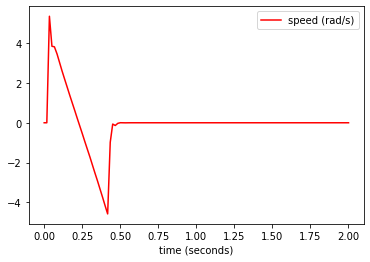

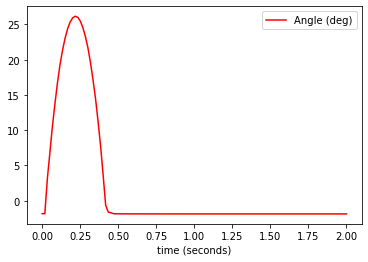

In [18]:
#
# to be tested with godot/single-joint-arm
#

import math
import arslabrobotics as ar

dps = ar.data.DataPlotter()
dps.set_x("time (seconds)")
dps.add_y("speed", "speed (rad/s)")

dpa = ar.data.DataPlotter()
dpa.set_x("time (seconds)")
dpa.add_y("angle", "Angle (deg)")

dds = ar.dds.DDS()
dds.start()

dds.subscribe(['speed','angle'])
dds.publish('torque', 30, ar.dds.DDS_TYPE_FLOAT)

t = ar.utils.Time()
t.start()
while t.get() < 2:
    
    v = dds.wait('speed')
    p = dds.read('angle')
    
    delta_t = t.elapsed()

    dps.append_x(t.get())
    dps.append_y("speed", v)
    
    dpa.append_x(t.get())
    dpa.append_y("angle", math.degrees(p))

    dds.publish('torque', 0.0, ar.dds.DDS_TYPE_FLOAT)

dps.plot()
dpa.plot()

dds.stop()

